# Q2c: Train a Global Model (e.g. Prophet) using other variables

**INSTRUCTIONS TO USER:**
1. Ensure `prophet` is installed.
2. Use the Airline dataset.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX


Forecasting regressors...
Forecasting passengers...


c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: 

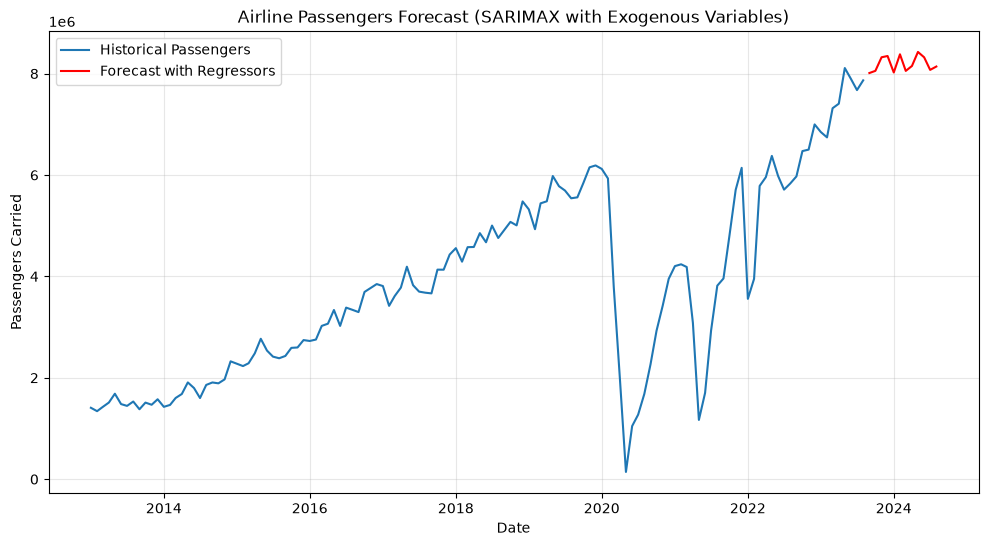

In [14]:
# 1. Load Data
df = pd.read_csv('airline_dataset.csv', thousands=',')
df.columns = df.columns.str.strip() 
month_abbr = df['MONTH'].astype(str).str[:3]
df['Date'] = pd.to_datetime(month_abbr + '-' + df['YEAR'].astype(str), format='%b-%Y')

# 2. Format & Rename Columns
rename_map = {
    'PASSENGERS CARRIED': 'y',
    'TOTAL DEPARTURES': 'departures',
    'HOURS FLOWN': 'flight_hours',
    'KILOMETRE FLOWN': 'distance_flown',
    'AVAILABLE SEAT KILOMETRE (IN THOUSAND)': 'available_seat_kilometers',
    'FREIGHT CARRIED (IN TONNE)': 'freight_carried',
    'MAIL CARRIED (IN TONNE)': 'mail_carried'
}
df = df.rename(columns=rename_map)
other_cols = ['departures', 'flight_hours', 'distance_flown', 'available_seat_kilometers', 'freight_carried', 'mail_carried']

# Interpolate missing values
numeric_cols = ['y'] + other_cols
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

# Train Split (Set Date as index for SARIMAX)
train = df[['Date', 'y'] + other_cols].sort_values('Date').set_index('Date')

# 3. Forecast the future values of the Regressors
print("Forecasting regressors...")
future_dates = pd.date_range(start='2023-09-01', periods=12, freq='MS')
future_regressors = pd.DataFrame(index=future_dates)

for col in other_cols:
    # Use simple ARIMA(1,1,0) to forecast the future regressors
    m_reg = SARIMAX(train[col], order=(1,1,0))
    res_reg = m_reg.fit(disp=False)
    future_regressors[col] = res_reg.forecast(steps=12)

# 4. Modeling - Main Passenger Forecast with Regressors (exog)
print("Forecasting passengers...")
# Notice we pass `exog=train[other_cols]` to train it on the other variables!
m = SARIMAX(train['y'], exog=train[other_cols], order=(1,1,1), seasonal_order=(1,1,1,12))
res = m.fit(disp=False)

# 5. Forecasting
# We must pass the future regressors we predicted in Step 3!
forecast = res.forecast(steps=12, exog=future_regressors)

# 6. Evaluate / Visualize
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['y'], label='Historical Passengers')
plt.plot(forecast.index, forecast, label='Forecast with Regressors', color='red')
plt.title("Airline Passengers Forecast (SARIMAX with Exogenous Variables)")
plt.xlabel("Date")
plt.ylabel("Passengers Carried")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
